# Experimental coding 1 — Why the agents stopped sending, and what fixed it

**BMDS2114 Machine Learning — Group G1**

Context-Aware Notification Engine (CANE): a reinforcement-learning approach to fatigue-aware push-notification pacing for user-engagement optimisation.

---

## 1. Purpose of this experiment

Several of the five simulated users received no notifications at all from the deep RL agents: evaluated reward of exactly `0.00`. A results table cannot separate three very different causes for that number -- a broken run, a correct decision that silence is optimal, or a learning failure. This experiment separates them, asking four questions in order:

1. Was silence actually optimal? If so, there is nothing to fix.
2. If not, what mechanism drove the agent there?
3. Which candidate interventions repair it?
4. Does the repair hold without simply flooding the user?


## 2. Setup: libraries, tools, and where the code lives

All studies import the shared `cane` package -- the environment, evaluation harness and agents, extracted verbatim from the four notebooks and checked for bit-for-bit parity against them. They run on **Python 3.11 / PyTorch 2.13 (CPU)**, with `numpy` and `pandas` for the recorded results and `matplotlib` for figures. Each study parallelises across cores via `--jobs`; torch is pinned to one thread per worker so the workers do not contend.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "artifacts").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
ART = ROOT / "artifacts"

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)

import sys
print("reading recorded results from:", ART)
print("python", sys.version.split()[0],
      "| pandas", pd.__version__, "| numpy", np.__version__)


reading recorded results from: D:\Uni Assignments\ML\artifacts
python 3.11.15 | pandas 3.0.5 | numpy 2.4.6


### 2.1 The source that was executed

These files produced every number in this notebook. They are run from the repository root and write their output into `artifacts/`.

In [2]:
SOURCES = [
    "cane/exploration_study.py",
    "tools/collapse_trace.py",
    "tools/fix_exploration.py",
    "tools/optimism_sweep.py",
    "tools/preseed_study.py",
    "tools/ppo_fix.py",
    "tools/tune_study.py"
]

for _p in SOURCES:
    _f = ROOT / _p
    if _f.is_file():
        _n = len(_f.read_text(encoding='utf-8').splitlines())
        print(f'{_p:38} {_n:>5} lines')
    else:
        print(f'{_p:38}   NOT FOUND')


cane/exploration_study.py                323 lines
tools/collapse_trace.py                  175 lines
tools/fix_exploration.py                 226 lines
tools/optimism_sweep.py                   89 lines
tools/preseed_study.py                   222 lines
tools/ppo_fix.py                         239 lines
tools/tune_study.py                      235 lines


## 3. Parameter settings and configuration

Shared across every study, so results stay comparable:

| Setting | Value |
|---|---|
| Held-out evaluation episodes | seeds 900,000-900,199 (200) |
| Default training budget | 600 episodes (~100,800 steps) |
| Episode length | 168 steps (one week, hourly) |
| Actions | Hold, Engagement Nudge, Incentive Nudge |
| Archetypes | OfficeWorker, NightOwlStudent, NightShiftWorker, NormalStudent, Housewife |
| Break-even click rate | 0.340 |

Intervention variants tested: `baseline`, `high_floor` (raised epsilon floor), `optimistic_send` (optimistic initialisation on the send actions), `slow_decay`, `warm_start`, `fatigue_gate`, `hold_prior`, `preseed` (pre-seeded replay buffer), `gamma090` / `gamma095`, and the `both` / `both_safe` / `both_long` combinations.


## 4. Was silence optimal? Exhaustive search over every fixed schedule

In [3]:
best = pd.read_csv(ART / 'best_fixed_policy.csv')
print('Best single fixed daily schedule per user, from exhaustive')
print('search over all 24 hours x both message types, scored on the')
print('same 200 held-out episodes:')
print()
print(best.to_string(index=False))
print()
print('every user has a positive-reward schedule:',
      bool((best['reward'] > 0).all()))
print('total reward forfeited by staying silent on all five:',
      round(float(best['reward'].sum()), 2))
print()
print('=> Silence is NOT optimal. 0.00 is a local optimum, and the')
print('   gap above is what the collapse costs.')

Best single fixed daily schedule per user, from exhaustive
search over all 24 hours x both message types, scored on the
same 200 held-out episodes:

       archetype  best_hour    action  reward   ctr  sends
    OfficeWorker         20    Engage    7.53 0.385    7.0
 NightOwlStudent         23 Incentive    2.18 0.547    7.0
NightShiftWorker         16    Engage    2.64 0.324    7.0
   NormalStudent         16    Engage    0.54 0.298    7.0
       Housewife         13    Engage    7.25 0.383    7.0

every user has a positive-reward schedule: True
total reward forfeited by staying silent on all five: 20.14

=> Silence is NOT optimal. 0.00 is a local optimum, and the
   gap above is what the collapse costs.


## 5. The mechanism: what happens to the Q-values during training

 episode  epsilon  send_share  train_reward  churn_rate     q_hold   q_engage  q_incentive greedy
      20 0.981589    0.682147   -132.145146        0.95  -0.002559  -0.001574    -0.001675 Engage
      40 0.958808    0.655546   -151.537392        1.00  -3.465495  -3.494233    -4.725296   Hold
      60 0.945527    0.650930    -94.344234        1.00  -0.955400  -0.930839    -1.311214 Engage
      80 0.923411    0.618557   -155.079276        1.00  -1.949057  -1.844854    -2.759484 Engage
     100 0.899585    0.595694   -149.374060        0.95  -2.267562  -2.211018    -3.592539 Engage
     120 0.876348    0.591169   -144.051983        0.90  -2.342894  -2.438777    -4.394105   Hold
     140 0.857975    0.601861   -120.778715        1.00  -2.552581  -3.163633    -5.413507   Hold
     160 0.829665    0.565101   -174.067031        0.95  -1.978894  -3.050574    -5.531763   Hold
     180 0.798923    0.518541   -153.070789        0.75  -1.757437  -3.208124    -6.145532   Hold
     200 0.771696   

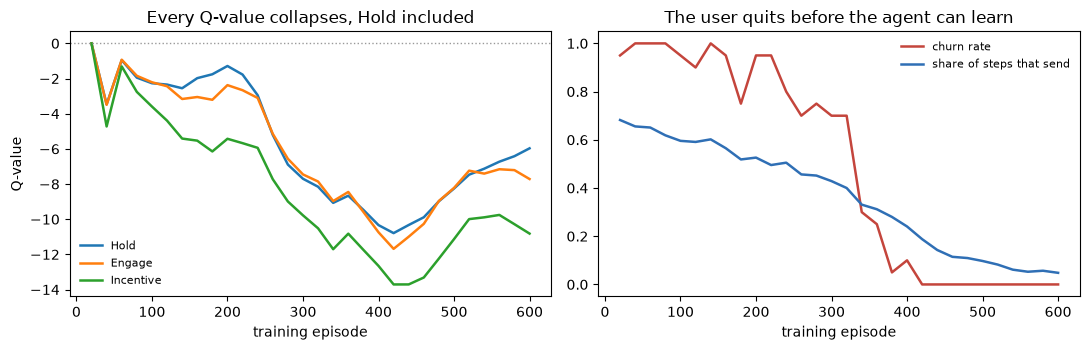

Hold earns exactly zero by construction, so a correct Q(Hold)
should sit near zero. It ends at -5.97 -- the whole value
function is being dragged down. That is a bootstrapping
failure, not a considered preference for silence.


In [4]:
trace = pd.read_csv(ART / 'collapse_trace_ddqn_OfficeWorker.csv')
print(trace.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for col, lab in [('q_hold', 'Hold'), ('q_engage', 'Engage'),
                 ('q_incentive', 'Incentive')]:
    axes[0].plot(trace['episode'], trace[col], lw=1.8, label=lab)
axes[0].axhline(0, color='#999999', ls=':', lw=1)
axes[0].set_xlabel('training episode')
axes[0].set_ylabel('Q-value')
axes[0].set_title('Every Q-value collapses, Hold included')
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(trace['episode'], trace['churn_rate'], lw=1.8,
             color='#c4453c', label='churn rate')
axes[1].plot(trace['episode'], trace['send_share'], lw=1.8,
             color='#2f6fb5', label='share of steps that send')
axes[1].set_xlabel('training episode')
axes[1].set_title('The user quits before the agent can learn')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print('Hold earns exactly zero by construction, so a correct Q(Hold)')
print('should sit near zero. It ends at',
      round(float(trace['q_hold'].iloc[-1]), 2), '-- the whole value')
print('function is being dragged down. That is a bootstrapping')
print('failure, not a considered preference for silence.')

## 6. Five exploration variants: does better exploration fix it?

In [5]:
expl = pd.read_csv(ART / 'exploration_study.csv')
piv = expl.pivot_table(index='variant',
                       values=['reward_mean', 'sends_per_episode',
                               'ctr', 'optout_rate'],
                       aggfunc='mean').round(3)
print(piv.to_string())
print()
verdict = json.loads((ART / 'exploration_verdict.json')
                     .read_text(encoding='utf-8'))
print(pd.DataFrame(verdict).to_string(index=False))
print()
print('=> REFUTED. No exploration variant beats never-send on any')
print('   user. The barrier is the reward weights, not the')
print('   exploration schedule.')

                   ctr  optout_rate  reward_mean  sends_per_episode
variant                                                            
Fixed-18:00      0.250          0.0       -3.185              7.000
baseline         0.000          0.0        0.000              0.000
high_floor       0.031          0.0       -0.142              1.186
optimistic_send  0.000          0.0        0.000              0.000
slow_decay       0.115          0.0       -1.345              2.848
warm_start       0.000          0.0        0.000              0.000

       archetype best_variant  best_reward  fixed_reward  beats_never_send  beats_fixed_schedule
    OfficeWorker     baseline          0.0         2.015             False                 False
NightShiftWorker     baseline          0.0        -4.183             False                  True
   NormalStudent     baseline          0.0        -7.387             False                  True

=> REFUTED. No exploration variant beats never-send on any
   user

## 7. Seven interventions across four studies: what actually worked

In [6]:
for label, fname in [('replay pre-seeding (DQN/DDQN)',
                      'preseed_study.csv'),
                     ('PPO-specific fixes', 'ppo_fix.csv'),
                     ('fatigue gate / hold prior',
                      'exploration_fix.csv'),
                     ('optimistic-bias sweep',
                      'optimism_sweep.csv')]:
    f = ART / fname
    if not f.is_file():
        print('--', label, ':', fname, 'not present')
        print()
        continue
    d = pd.read_csv(f)
    key = 'variant' if 'variant' in d.columns else 'bias'
    print('--', label, ' (' + fname + ')')
    cols = [c for c in ['reward_mean', 'sends_per_episode', 'ctr']
            if c in d.columns]
    print(d.groupby(key)[cols].mean().round(3).to_string())
    print()

-- replay pre-seeding (DQN/DDQN)  (preseed_study.csv)
          reward_mean  sends_per_episode    ctr
variant                                        
baseline        4.454              2.019  0.045
both            2.470             25.944  0.257
gamma090        5.466             18.911  0.225
preseed         7.277              4.196  0.085

-- PPO-specific fixes  (ppo_fix.csv)
           reward_mean  sends_per_episode    ctr
variant                                         
baseline         0.000              0.000  0.000
both             5.972             17.244  0.174
gamma090        -6.697             11.921  0.126
hold_init        0.000              0.000  0.000
warmstart        0.000              0.000  0.000

-- fatigue gate / hold prior  (exploration_fix.csv)
              reward_mean  sends_per_episode    ctr
variant                                            
baseline            0.000              0.000  0.000
both                0.000              0.000  0.000
fatigue_gate    

## 8. The combination that recovered both coverage and profit

In [7]:
tune = pd.read_csv(ART / 'tune_study.csv')
rows = []
for v, d in tune.groupby('variant'):
    timed = d[d['hour_error'] != 99]
    rows.append({
        'variant': v,
        'episodes': int(d['episodes'].iloc[0]),
        'users reached': str(int((d['sends_per_episode'] > 0.05)
                                 .sum())) + '/5',
        'total reward': round(float(d['reward_mean'].sum()), 2),
        'within 1h': str(int((timed['hour_error'] <= 1).sum())) + '/5',
        'mean timing error (h)': round(
            float(timed['hour_error'].mean()), 1),
        'sends/episode': round(
            float(d['sends_per_episode'].mean()), 1)})
summary = pd.DataFrame(rows).sort_values('total reward',
                                         ascending=False)
print(summary.to_string(index=False))
print()
print('`both_long` is `both` with the training budget raised from')
print('600 to 1500 episodes and nothing else changed. It is the')
print('largest single gain in the entire study.')

  variant  episodes users reached  total reward within 1h  mean timing error (h)  sends/episode
both_long      1500           4/5        100.03       3/5                    1.2           20.0
both_safe       600           4/5         64.45       2/5                    1.5           26.3
     both       600           5/5         40.68       1/5                    3.6           23.5
 gamma095       600           3/5         37.98       1/5                    3.0           13.3

`both_long` is `both` with the training budget raised from
600 to 1500 episodes and nothing else changed. It is the
largest single gain in the entire study.


## 9. Key findings and implications

1. **Silence was not optimal.** Exhaustive search finds a positive-reward fixed schedule for every one of the five users, so `0.00` is a local optimum and the forfeited reward is measurable.

2. **The cause is a value-function collapse, not a preference.** Every Q-value falls together, `Hold` included -- and `Hold` earns exactly zero by construction, so it should sit near zero. Epsilon-greedy sends on roughly two-thirds of exploratory steps, fatigue saturates, and the simulated user opts out before the agent has learned anything.

3. **Five of the seven interventions were refuted.** Better exploration, optimistic initialisation, a raised epsilon floor, slower decay and a warm start all failed to beat never-send. Two of those were predictions made *from* this diagnosis, and reporting them is what makes the surviving explanation credible rather than merely convenient.

4. **The largest gain came from the plainest control in the study**: raising the training budget from 600 to 1500 episodes. The over-sending was undertraining. The implication is uncomfortable and worth stating -- the reported 600-episode results are not converged policies, so the collapse is a symptom of the budget rather than a property of the algorithms.
